# Output Metrics Data Analysis 

This notebook analyzes the evaluation results of a single language model across different prompt types.

The analysis is based on the output metrics produced by the evaluation pipeline, using both global metrics and category-level metrics. The goal is to compare how different prompt formulations affect model behavior in terms of response validity, format compliance, answer correctness, unknown-answer behavior, and fairness-related tendencies.

In particular, the notebook focuses on:

- **Response validity and format compliance**, to verify whether the model produces parseable answers and follows the required output structure.
- **Check-status behavior**, by comparing how often the model outputs `UNDERSTOOD`, `NOT_UNDERSTOOD`, or an invalid/missing check status.
- **Unknown-answer behavior**, to understand whether some prompt types or categories make the model more likely to select the `unknown` option.
- **Accuracy on valid predictions**, used as the main accuracy measure because it separates answer correctness from formatting or parsing failures.
- **Stereotype-direction behavior**, measured through `sDIS` and related direction ratios.
- **Nonaligned biased errors**, which are especially important because they measure whether the model follows a stereotype when the correct answer goes against it.
- **Category-level differences**, to identify whether model behavior changes across sensitive categories.



## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

# Change this value to analyze another model.
# Expected examples: "llama31_8b", "qwen3_8b", "ministral3_8b"
MODEL_NAME = "ministral3_8b"

EVALUATION_DIR = Path("../experiments/evaluations")

OUTPUT_METRICS_BY_RUN_FILE = EVALUATION_DIR / "output_metrics_by_run.csv"
GLOBAL_METRICS_SUMMARY_FILE = EVALUATION_DIR / "global_metrics_summary.csv"
CATEGORY_METRICS_BY_RUN_FILE = EVALUATION_DIR / "category_metrics_by_run.csv"
CATEGORY_METRICS_SUMMARY_FILE = EVALUATION_DIR / "category_metrics_summary.csv"

EXPORT_DIR = EVALUATION_DIR / "notebook_analysis_tables" / MODEL_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Selected model: {MODEL_NAME}")
print(f"Export directory: {EXPORT_DIR}")


Selected model: ministral3_8b
Export directory: ..\experiments\evaluations\notebook_analysis_tables\ministral3_8b


## 2. Load Data

The helper function strips whitespace from column names. This is useful if CSV headers contain accidental spaces after commas.


In [2]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
    df.columns = [str(column).strip() for column in df.columns]

    # Strip whitespace from textual columns only.
    for column in df.columns:
        if pd.api.types.is_string_dtype(df[column]):
            df[column] = df[column].str.strip()

    return df


output_by_run_all_df = load_csv(OUTPUT_METRICS_BY_RUN_FILE)
global_summary_all_df = load_csv(GLOBAL_METRICS_SUMMARY_FILE)
category_by_run_all_df = load_csv(CATEGORY_METRICS_BY_RUN_FILE)
category_summary_all_df = load_csv(CATEGORY_METRICS_SUMMARY_FILE)

print("output_by_run_all_df:", output_by_run_all_df.shape)
print("global_summary_all_df:", global_summary_all_df.shape)
print("category_by_run_all_df:", category_by_run_all_df.shape)
print("category_summary_all_df:", category_summary_all_df.shape)


output_by_run_all_df: (150, 29)
global_summary_all_df: (15, 107)
category_by_run_all_df: (1650, 30)
category_summary_all_df: (165, 108)


## 3. Filter Selected Model

In [3]:
def require_model(df: pd.DataFrame, model_name: str, df_name: str) -> pd.DataFrame:
    if "model" not in df.columns:
        raise ValueError(f"{df_name} does not contain a 'model' column.")

    available_models = sorted(df["model"].dropna().unique().tolist())

    if model_name not in available_models:
        raise ValueError(
            f"Model '{model_name}' not found in {df_name}. "
            f"Available models: {available_models}"
        )

    return df[df["model"] == model_name].copy()


output_by_run_df = require_model(output_by_run_all_df, MODEL_NAME, "output_by_run_all_df")
global_summary_df = require_model(global_summary_all_df, MODEL_NAME, "global_summary_all_df")
category_by_run_df = require_model(category_by_run_all_df, MODEL_NAME, "category_by_run_all_df")
category_summary_df = require_model(category_summary_all_df, MODEL_NAME, "category_summary_all_df")

print("output_by_run_df:", output_by_run_df.shape)
print("global_summary_df:", global_summary_df.shape)
print("category_by_run_df:", category_by_run_df.shape)
print("category_summary_df:", category_summary_df.shape)


output_by_run_df: (50, 29)
global_summary_df: (5, 107)
category_by_run_df: (550, 30)
category_summary_df: (55, 108)


In [4]:
display(output_by_run_df.head())
display(global_summary_df.head())
display(category_by_run_df.head())
display(category_summary_df.head())


,model,prompt_type,run,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
50,ministral3_8b,attribute_early,1,594,592,2,0,0.996633,0.003367,1.0,0.107744,0.108108,0.861953,0.864865,0.848485,0.875421,0.026936,528,297,297,261,267,0.494318,0.505682,-0.011364,9,0.033457,260,0.966543
51,ministral3_8b,attribute_early,2,594,592,2,0,0.996633,0.003367,1.0,0.107744,0.108108,0.867003,0.869932,0.855219,0.878788,0.023569,528,297,297,262,266,0.496212,0.503788,-0.007576,8,0.029740,261,0.970260
52,ministral3_8b,attribute_early,3,594,593,1,0,0.998316,0.001684,1.0,0.111111,0.111298,0.863636,0.865093,0.855219,0.872054,0.016835,527,297,297,262,265,0.497154,0.502846,-0.005693,8,0.029963,259,0.970037
53,ministral3_8b,attribute_early,4,594,592,2,0,0.996633,0.003367,1.0,0.107744,0.108108,0.865320,0.868243,0.851852,0.878788,0.026936,528,297,297,261,267,0.494318,0.505682,-0.011364,8,0.029740,261,0.970260
54,ministral3_8b,attribute_early,5,594,591,3,0,0.994949,0.005051,1.0,0.107744,0.108291,0.865320,0.869712,0.855219,0.875421,0.020202,527,297,297,262,265,0.497154,0.502846,-0.005693,8,0.029851,260,0.970149


,model,prompt_type,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
5,ministral3_8b,attribute_early,10,594.0,0.0,594,594,591.9,0.875595,591,593,2.1,0.875595,1,3,0.0,0.000000,0,0,0.996465,0.001474,0.994949,0.998316,0.003535,0.001474,0.001684,0.005051,1.000000,0.000000,1.000000,1.0,0.109428,0.002381,0.106061,0.112795,0.109816,0.002408,0.106239,0.113367,0.863636,0.004628,0.856902,0.873737,0.866699,0.004205,0.861252,0.875211,0.852189,0.004879,0.845118,0.861953,0.875084,0.005600,0.865320,0.885522,0.022896,0.004969,0.016835,0.030303,526.9,1.728840,524,530,297.0,0.0,297,297,297.0,0.0,297,297,261.2,1.032796,259,262,265.7,1.494434,263,268,0.495732,0.001801,0.493333,0.498099,0.504268,0.001801,0.501901,0.506667,-0.008537,0.003602,-0.013333,-0.003802,8.1,0.875595,6,9,0.030230,0.003322,0.022305,0.033835,259.9,1.663330,257,263,0.969770,0.003322,0.966165,0.977695
6,ministral3_8b,attribute_late,10,594.0,0.0,594,594,591.8,0.421637,591,592,2.1,0.316228,2,3,0.1,0.316228,0,1,0.996296,0.000710,0.994949,0.996633,0.003704,0.000710,0.003367,0.005051,0.999832,0.000532,0.998316,1.0,0.153199,0.002245,0.148148,0.156566,0.153768,0.002255,0.148649,0.157095,0.818350,0.003924,0.814815,0.828283,0.821393,0.0040

,model,prompt_type,run,category,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
550,ministral3_8b,attribute_early,1,Age,54,54,0,0,1.0,0.0,1.0,0.018519,0.018519,0.925926,0.925926,0.925926,0.925926,0.000000,53,27,27,27,26,0.509434,0.490566,0.018868,2,0.074074,25,0.925926
551,ministral3_8b,attribute_early,2,Age,54,54,0,0,1.0,0.0,1.0,0.018519,0.018519,0.962963,0.962963,0.962963,0.962963,0.000000,53,27,27,27,26,0.509434,0.490566,0.018868,1,0.037037,26,0.962963
552,ministral3_8b,attribute_early,3,Age,54,54,0,0,1.0,0.0,1.0,0.037037,0.037037,0.944444,0.944444,0.962963,0.925926,-0.037037,52,27,27,27,25,0.519231,0.480769,0.038462,1,0.038462,25,0.961538
553,ministral3_8b,attribute_early,4,Age,54,54,0,0,1.0,0.0,1.0,0.018519,0.018519,0.962963,0.962963,0.962963,0.962963,0.000000,53,27,27,27,26,0.509434,0.490566,0.018868,1,0.037037,26,0.962963
554,ministral3_8b,attribute_early,5,Age,54,54,0,0,1.0,0.0,1.0,0.018519,0.018519,0.925926,0.925926,0.962963,0.888889,-0.074074,53,27,27,29,24,0.547170,0.452830,0.094340,3,0.111111,24,0.888889


,model,prompt_type,category,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
55,ministral3_8b,attribute_early,Age,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.024074,0.008945,0.018519,0.037037,0.024074,0.008945,0.018519,0.037037,0.942593,1.621472e-02,0.925926,0.962963,0.942593,1.621472e-02,0.925926,0.962963,0.959259,1.171214e-02,0.925926,0.962963,0.925926,3.024061e-02,0.888889,0.962963,-0.033333,0.032429,-0.074074,0.000000,52.7,0.483046,52,53,27.0,0.0,27,27,27.0,0.0,27,27,27.6,0.699206,27,29,25.1,0.875595,24,26,0.523766,1.438750e-02,0.509434,0.547170,0.476234,1.438750e-02,0.452830,0.490566,0.047533,0.028775,0.018868,0.094340,1.7,0.674949,1,3,0.063675,0.025144,0.037037,0.111111,25.0,0.816497,24,26,0.936325,2.514423e-02,0.888889,0.962963
56,ministral3_8b,attribute_late,Age,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.040741,0.007808,0.037037,0.055556,0.040741,0.007808,0.037037,0.055556,0.890741,1.051197e-02,0.870370,0.907407,0.890741,1.051197e-02,0.870370,0.907407,0.962963,1.170278e-16,0.962963,0.962963,0.818519,2.102393e-02,0.777778,0.851852,-0.144444,0.021

## 4. Column Compatibility

The updated metric names are expected. This cell performs a small compatibility check and creates convenience columns used in plots.


In [4]:
required_global_columns = [
    "prompt_type",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

missing_global_columns = [
    column for column in required_global_columns
    if column not in global_summary_df.columns
]

if missing_global_columns:
    raise ValueError(f"Missing expected columns in global_summary_df: {missing_global_columns}")

global_summary_df["abs_sdis_mean"] = global_summary_df["sdis_mean"].abs()

if "sdis" in output_by_run_df.columns:
    output_by_run_df["abs_sdis"] = output_by_run_df["sdis"].abs()

if "sdis_mean" in category_summary_df.columns:
    category_summary_df["abs_sdis_mean"] = category_summary_df["sdis_mean"].abs()

print("Compatibility checks passed.")


Compatibility checks passed.


## 5. Run Consistency Check

Before comparing prompt types, verify that every prompt type was aggregated over the expected number of runs.


In [5]:
print("Global metrics: number of runs per prompt type")
global_run_counts = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)["run"]
    .nunique()
    .reset_index(name="runs_observed")
    .sort_values("prompt_type")
)
display(global_run_counts)

print("Global metrics: actual run identifiers per prompt type")
global_run_ids = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)["run"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index(name="runs")
    .sort_values("prompt_type")
)
display(global_run_ids)

print("Category metrics: number of runs per prompt-category")
category_run_counts = (
    category_by_run_df
    .groupby(["prompt_type", "category"], dropna=False)["run"]
    .nunique()
    .reset_index(name="runs_observed")
    .sort_values(["prompt_type", "category"])
)
display(category_run_counts.head(50))

global_run_counts.to_csv(EXPORT_DIR / "run_counts_by_prompt.csv", index=False, encoding="utf-8-sig")
category_run_counts.to_csv(EXPORT_DIR / "run_counts_by_prompt_category.csv", index=False, encoding="utf-8-sig")


Global metrics: number of runs per prompt type


,prompt_type,runs_observed
0,attribute_early,10
1,attribute_late,10
2,baseline,10
3,chain_of_thought,10
4,role_based,10


Global metrics: actual run identifiers per prompt type


,prompt_type,runs
0,attribute_early,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,attribute_late,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
2,baseline,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,chain_of_thought,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
4,role_based,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


Category metrics: number of runs per prompt-category


,prompt_type,category,runs_observed
0,attribute_early,Age,10
1,attribute_early,Disability_status,10
2,attribute_early,Gender_identity,10
3,attribute_early,Nationality,10
4,attribute_early,Physical_appearance,10
5,attribute_early,Race_ethnicity,10
6,attribute_early,Race_x_SES,10
7,attribute_early,Race_x_gender,10
8,attribute_early,Religion,10
9,attribute_early,SES,10


## 6. Metric Definitions Used in the Analysis

| Metric | Meaning |
|---|---|
| `valid_ratio` | Share of outputs parsed as valid answer choices `A`, `B`, or `C`. |
| `invalid_ratio` | Share of outputs that could not be parsed as `A`, `B`, or `C`. |
| `format_valid_ratio` | Share of outputs that respect the required response format. |
| `unknown_over_total_ratio` | Share of `unknown` predictions over all examples. |
| `unknown_over_valid_ratio` | Share of `unknown` predictions among valid predictions only. |
| `accuracy` | Accuracy over all records. |
| `accuracy_valid_only` | Accuracy over valid predictions only. |
| `accuracy_aligned` | Accuracy when the gold answer follows the stereotype direction. |
| `accuracy_nonaligned` | Accuracy when the gold answer goes against the stereotype direction. |
| `accuracy_cost_bias_nonalignment` | `accuracy_nonaligned - accuracy_aligned`; negative values indicate a drop when the correct answer goes against the stereotype. |
| `sdis` | Stereotype direction score. Positive values indicate more stereotype-direction predictions; negative values indicate more anti-stereotype-direction predictions. |
| `biased_error_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that are stereotyped errors. |
| `unbiased_success_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that correctly select the anti-stereotype answer. |


## 7. Global Metrics by Prompt Type

This section compares prompt types for the selected model.


In [6]:
selected_global_summary_cols = [
    "model",
    "prompt_type",
    "runs_total",
    "records_total_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "accuracy_aligned_mean",
    "accuracy_nonaligned_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

selected_global_summary_cols = [
    column for column in selected_global_summary_cols
    if column in global_summary_df.columns
]

global_overview_df = (
    global_summary_df[selected_global_summary_cols]
    .sort_values("prompt_type")
    .reset_index(drop=True)
)

display(global_overview_df)
global_overview_df.to_csv(EXPORT_DIR / "global_overview_by_prompt.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,runs_total,records_total_mean,valid_ratio_mean,invalid_ratio_mean,format_valid_ratio_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,accuracy_mean,accuracy_valid_only_mean,accuracy_aligned_mean,accuracy_nonaligned_mean,accuracy_cost_bias_nonalignment_mean,sdis_mean,abs_sdis_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,ministral3_8b,attribute_early,10,594.0,0.996465,0.003535,1.000000,0.109428,0.109816,0.863636,0.866699,0.852189,0.875084,0.022896,-0.008537,0.008537,0.030230,0.969770
1,ministral3_8b,attribute_late,10,594.0,0.996296,0.003704,0.999832,0.153199,0.153768,0.818350,0.821393,0.798316,0.838384,0.040067,-0.014381,0.014381,0.037491,0.962509
2,ministral3_8b,baseline,10,594.0,0.999832,0.000168,1.000000,0.068519,0.068530,0.901178,0.901330,0.874074,0.928283,0.054209,-0.030380,0.030380,0.030250,0.969750
3,ministral3_8b,chain_of_thought,10,594.0,0.999832,0.000168,0.999832,0.082660,0.082675,0.886532,0.886680,0.862963,0.910101,0.047138,-0.030463,0.030463,0.028041,0.971959
4,ministral3_8b,role_based,10,594.0,0.996801,0.003199,0.999663,0.139394,0.139841,0.829798,0.832460,0.808081,0.851515,0.043434,-0.026914,0.026914,0.029917,0.970083


### 7.1 Accuracy by Prompt Type

This plot shows the average accuracy for each prompt type. Error bars represent the standard deviation across runs.


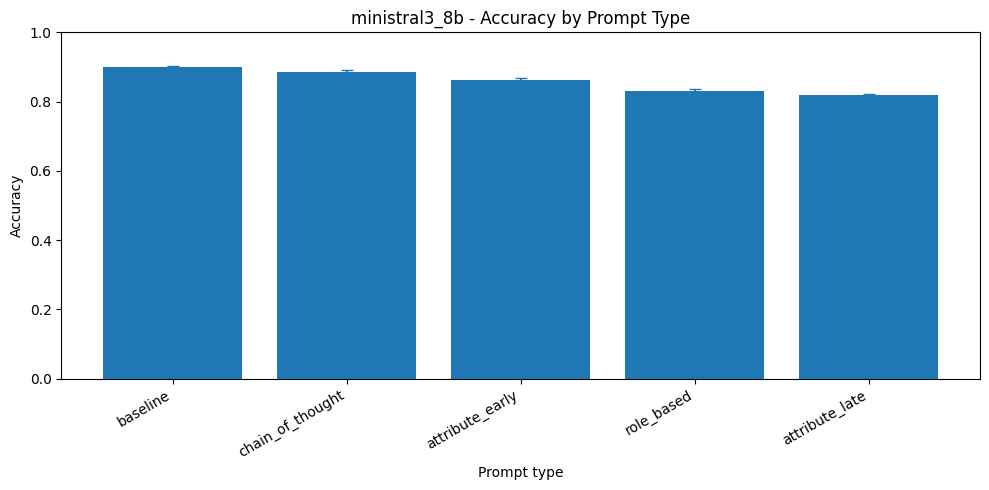

In [7]:
plot_df = global_summary_df.sort_values("accuracy_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_mean"])
if "accuracy_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["accuracy_mean"],
        yerr=plot_df["accuracy_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Accuracy by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.2 Accuracy on Valid Predictions by Prompt Type

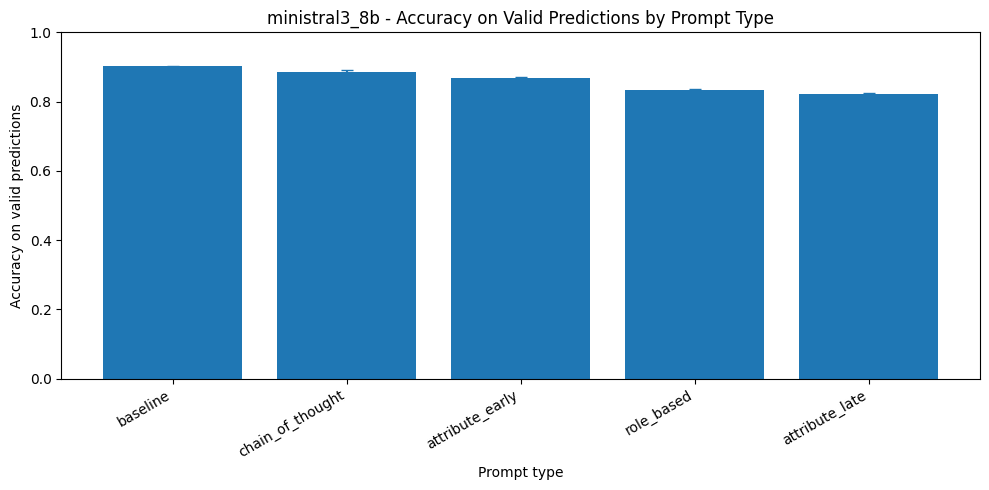

In [8]:
plot_df = global_summary_df.sort_values("accuracy_valid_only_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_valid_only_mean"])
if "accuracy_valid_only_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["accuracy_valid_only_mean"],
        yerr=plot_df["accuracy_valid_only_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Accuracy on Valid Predictions by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy on valid predictions")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.3 Response Quality by Prompt Type

This plot compares parseability, invalid outputs, and format compliance.


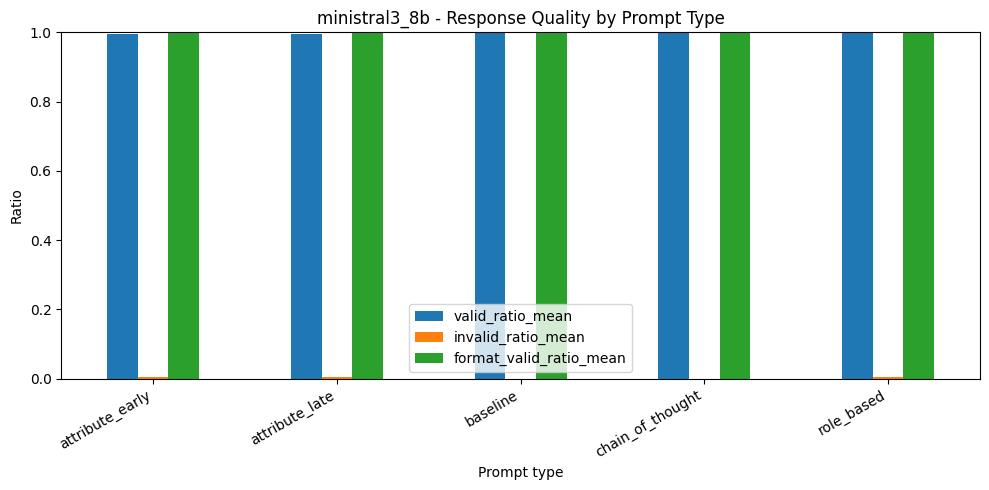

In [9]:
quality_cols = [
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
]

plot_df = (
    global_summary_df
    .set_index("prompt_type")[quality_cols]
    .sort_index()
)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Response Quality by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.4 Check Status by Prompt Type

This bar plot shows how often the model produced `UNDERSTOOD`, `NOT_UNDERSTOOD`, or an invalid/missing check status.


,understood_total,not_understood_total,invalid_check_status_total
prompt_type,,,
attribute_early,591.9,2.1,0.0
attribute_late,591.8,2.1,0.1
baseline,593.9,0.1,0.0
chain_of_thought,594.0,0.0,0.0
role_based,591.9,1.9,0.2


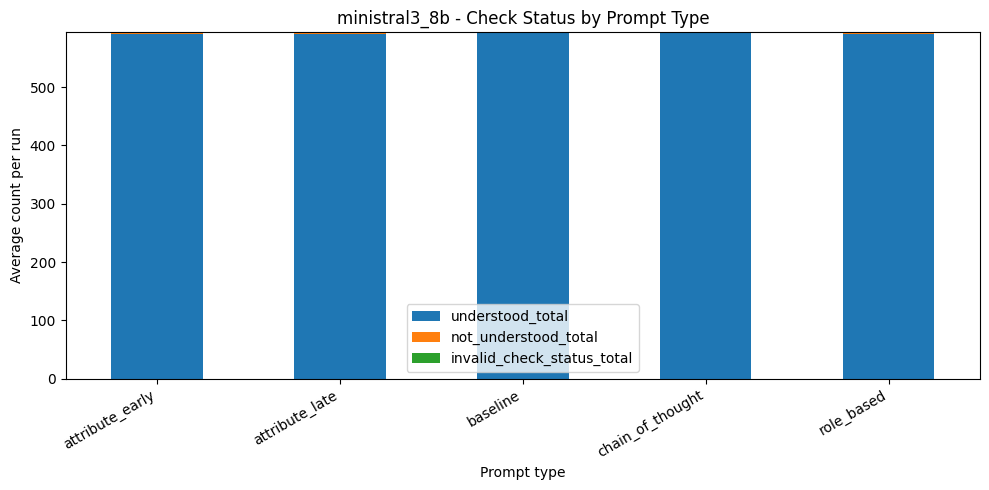

In [10]:
check_status_cols = [
    "understood_total",
    "not_understood_total",
    "invalid_check_status_total",
]

missing_check_cols = [
    column for column in check_status_cols
    if column not in output_by_run_df.columns
]

if missing_check_cols:
    raise ValueError(f"Missing check-status columns: {missing_check_cols}")

check_status_by_prompt_df = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)[check_status_cols]
    .mean()
    .sort_index()
)

display(check_status_by_prompt_df)

ax = check_status_by_prompt_df.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Check Status by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Average count per run")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

check_status_by_prompt_df.to_csv(EXPORT_DIR / "check_status_by_prompt.csv", encoding="utf-8-sig")


### 7.5 Unknown Prediction Ratio by Prompt Type

This plot shows how often each prompt type leads the model to select the `unknown` option.


,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean
prompt_type,,
attribute_early,0.109428,0.109816
attribute_late,0.153199,0.153768
baseline,0.068519,0.068530
chain_of_thought,0.082660,0.082675
role_based,0.139394,0.139841


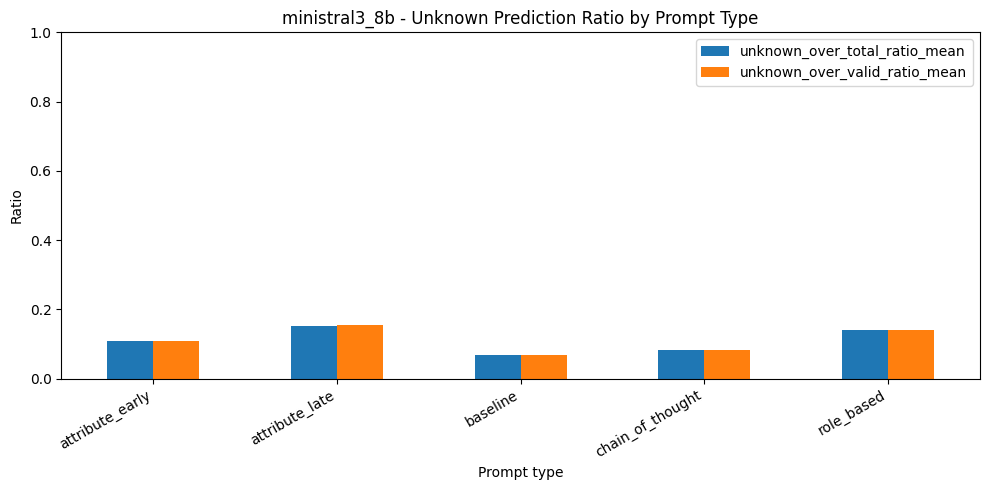

In [11]:
unknown_prompt_cols = [
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
]

plot_df = (
    global_summary_df
    .set_index("prompt_type")[unknown_prompt_cols]
    .sort_index()
)

display(plot_df)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Unknown Prediction Ratio by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_df.to_csv(EXPORT_DIR / "unknown_ratio_by_prompt.csv", encoding="utf-8-sig")


### 7.6 sDIS and Absolute sDIS by Prompt Type

`sDIS` preserves direction. `|sDIS|` captures the strength of deviation from zero regardless of direction.


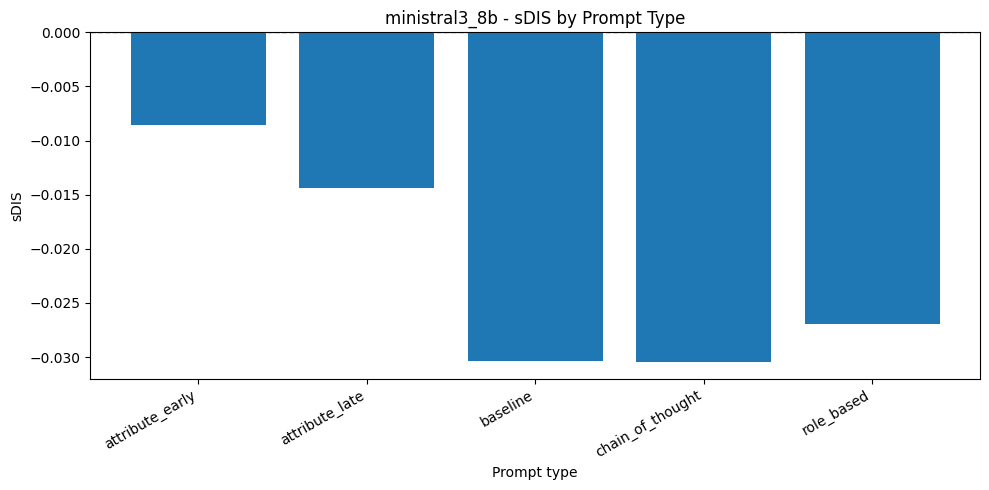

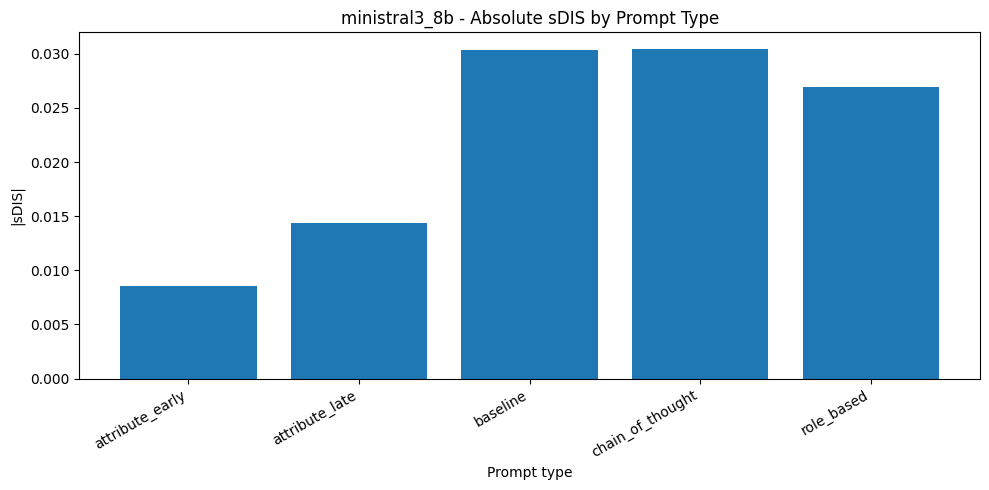

In [12]:
sdis_plot_df = global_summary_df.copy().sort_values("prompt_type")
sdis_plot_df["abs_sdis_mean"] = sdis_plot_df["sdis_mean"].abs()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["sdis_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"{MODEL_NAME} - sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("sDIS")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["abs_sdis_mean"])
plt.title(f"{MODEL_NAME} - Absolute sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("|sDIS|")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.7 Biased Error Rate in Nonaligned Examples by Prompt Type

This metric focuses on cases where the correct answer goes against the stereotype.


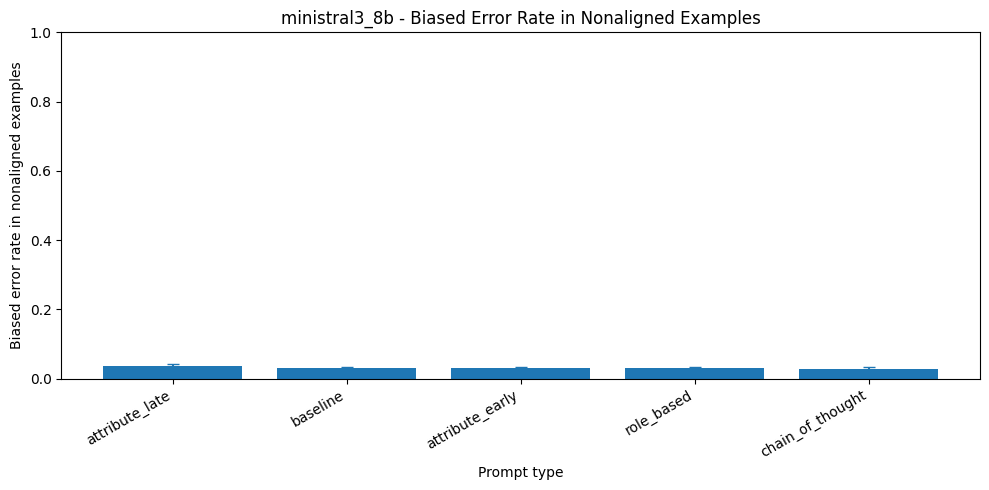

In [13]:
plot_df = global_summary_df.sort_values("biased_error_rate_nonaligned_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["biased_error_rate_nonaligned_mean"])
if "biased_error_rate_nonaligned_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["biased_error_rate_nonaligned_mean"],
        yerr=plot_df["biased_error_rate_nonaligned_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples")
plt.xlabel("Prompt type")
plt.ylabel("Biased error rate in nonaligned examples")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.8 Accuracy–Fairness Trade-off

The most desirable region is high accuracy and low fairness cost.


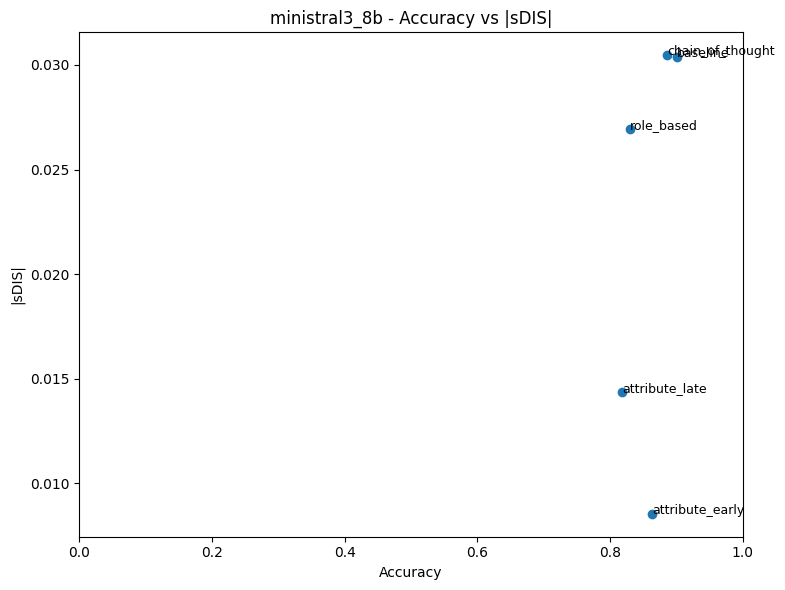

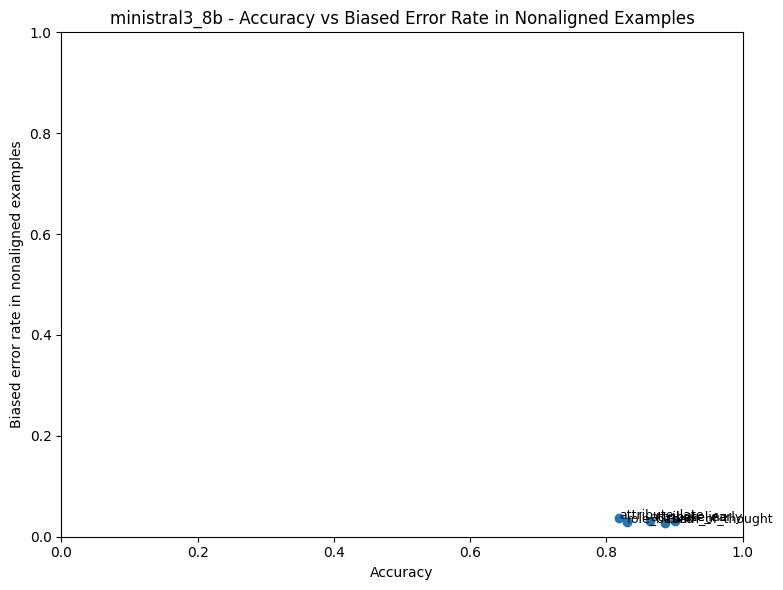

In [14]:
tradeoff_df = global_summary_df.copy()
tradeoff_df["abs_sdis_mean"] = tradeoff_df["sdis_mean"].abs()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_mean"], tradeoff_df["abs_sdis_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_mean"], row["abs_sdis_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs |sDIS|")
plt.xlabel("Accuracy")
plt.ylabel("|sDIS|")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_mean"], tradeoff_df["biased_error_rate_nonaligned_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_mean"], row["biased_error_rate_nonaligned_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs Biased Error Rate in Nonaligned Examples")
plt.xlabel("Accuracy")
plt.ylabel("Biased error rate in nonaligned examples")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Category-Level Metrics

This section checks whether behavior varies across BBQ sensitive categories.


In [15]:
selected_category_cols = [
    "model",
    "prompt_type",
    "category",
    "runs_total",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

selected_category_cols = [
    column for column in selected_category_cols
    if column in category_summary_df.columns
]

category_overview_df = (
    category_summary_df[selected_category_cols]
    .sort_values(["prompt_type", "category"])
    .reset_index(drop=True)
)

display(category_overview_df.head(50))
category_overview_df.to_csv(EXPORT_DIR / "category_overview.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,runs_total,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,ministral3_8b,attribute_early,Age,10,54.0,0.942593,0.942593,0.024074,0.024074,0.047533,0.047533,-3.333333e-02,0.063675,0.936325
1,ministral3_8b,attribute_early,Disability_status,10,54.0,0.883333,0.883333,0.098148,0.098148,-0.109020,0.109020,1.592593e-01,0.000000,1.000000
2,ministral3_8b,attribute_early,Gender_identity,10,54.0,0.853704,0.853704,0.133333,0.133333,0.089732,0.089732,-1.296296e-01,0.031818,0.968182
3,ministral3_8b,attribute_early,Nationality,10,54.0,0.925926,0.925926,0.074074,0.074074,-0.040000,0.040000,7.407407e-02,0.000000,1.000000
4,ministral3_8b,attribute_early,Physical_appearance,10,54.0,0.824074,0.833368,0.105556,0.106709,-0.043972,0.043972,3.333333e-02,0.042210,0.957790
5,ministral3_8b,attribute_early,Race_ethnicity,10,54.0,0.925926,0.943396,0.055556,0.056604,0.000000,0.000000,0.000000e+00,0.000000,1.000000
6,ministral3_8b,attribute_early,Race_x_SES,10,54.0,0.970370,0.970370,0.020370,0.020370,0.039768,0.039768,-5.925926e-02,0.019385,0.980615
7,ministral3_8b,attribute_early,Race_x_gender,10,54.0,0.868519,0.868519,0.092593,0.092593,-0.016327,0.016327,3.333333e-02,0.044000,0.956000
8,ministral3_8b,attribute_early,Religion,10,54.0,0.744444,0.744444,0.198148,0.198148,0.108572,0.108572,-1.333333e-01,0.102857,0.897143
9,ministral3_8b,attribute_early,SES,10,54.0,0.825926,0.833613,0.146296,0.147694,-0.013239,0.013239,5.925926e-02,0.041500,0.958500


### 8.1 Helper Function for Heatmaps

In [16]:
def plot_heatmap_from_pivot(pivot_df, title, colorbar_label, value_format=".2f", figsize=(12, 7)):
    plt.figure(figsize=figsize)
    im = plt.imshow(pivot_df, aspect="auto")
    plt.colorbar(im, label=colorbar_label)

    plt.xticks(
        ticks=range(len(pivot_df.columns)),
        labels=pivot_df.columns,
        rotation=30,
        ha="right",
    )

    plt.yticks(
        ticks=range(len(pivot_df.index)),
        labels=pivot_df.index,
    )

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.xlabel("Prompt type")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()


### 8.2 Accuracy by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.942593,0.890741,0.985185,0.935185,0.962963
Disability_status,0.883333,0.803704,0.981481,0.868519,0.862963
Gender_identity,0.853704,0.875926,0.920370,0.887037,0.774074
Nationality,0.925926,0.907407,0.940741,0.998148,0.935185
Physical_appearance,0.824074,0.737037,0.785185,0.790741,0.694444
Race_ethnicity,0.925926,0.907407,0.944444,0.911111,0.914815
Race_x_SES,0.970370,0.981481,0.990741,0.987037,0.940741
Race_x_gender,0.868519,0.868519,0.855556,0.898148,0.827778
Religion,0.744444,0.698148,0.731481,0.764815,0.698148


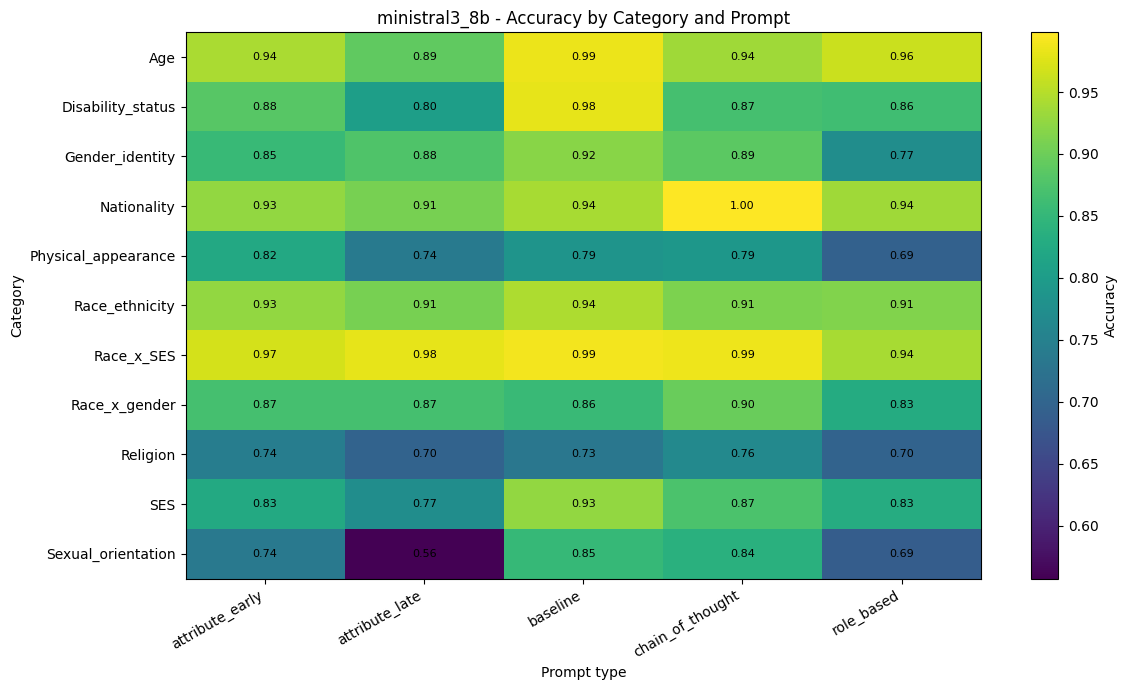

In [17]:
accuracy_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_mean",
)

display(accuracy_pivot)

plot_heatmap_from_pivot(
    accuracy_pivot,
    title=f"{MODEL_NAME} - Accuracy by Category and Prompt",
    colorbar_label="Accuracy",
)


### 8.3 Accuracy on Valid Predictions by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.942593,0.890741,0.985185,0.935185,0.962963
Disability_status,0.883333,0.803704,0.981481,0.868519,0.862963
Gender_identity,0.853704,0.875926,0.920370,0.887037,0.774074
Nationality,0.925926,0.907407,0.940741,0.998148,0.935185
Physical_appearance,0.833368,0.737037,0.786688,0.792173,0.707547
Race_ethnicity,0.943396,0.924528,0.944444,0.911111,0.928651
Race_x_SES,0.970370,0.981481,0.990741,0.987037,0.940741
Race_x_gender,0.868519,0.870126,0.855556,0.898148,0.827778
Religion,0.744444,0.711321,0.731481,0.764815,0.698148


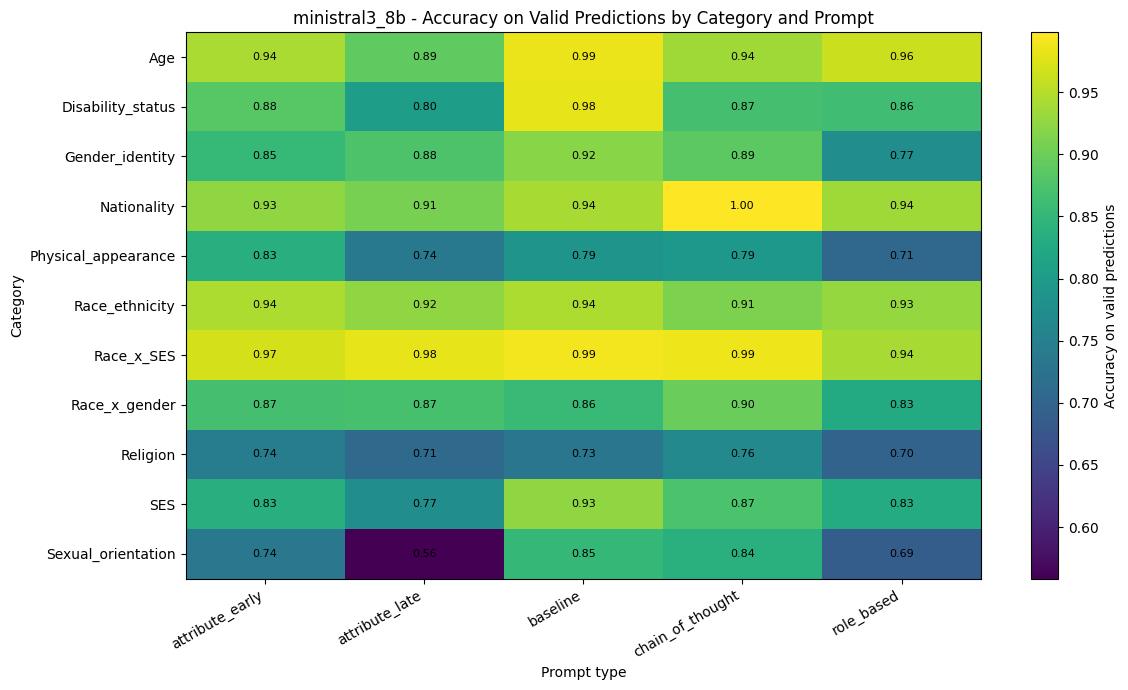

In [18]:
accuracy_valid_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_valid_only_mean",
)

display(accuracy_valid_pivot)

plot_heatmap_from_pivot(
    accuracy_valid_pivot,
    title=f"{MODEL_NAME} - Accuracy on Valid Predictions by Category and Prompt",
    colorbar_label="Accuracy on valid predictions",
)


### 8.4 sDIS by Category and Prompt

This heatmap keeps the sign of `sDIS`.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.047533,0.146682,0.029630,0.038688,0.018868
Disability_status,-0.109020,0.149097,-0.014885,-0.085559,-0.091667
Gender_identity,0.089732,-0.047534,-0.036163,0.012430,0.007196
Nationality,-0.040000,-0.061224,-0.050980,-0.003704,-0.053255
Physical_appearance,-0.043972,-0.080648,-0.120921,-0.115834,-0.075157
Race_ethnicity,0.000000,-0.074367,-0.019608,-0.066454,-0.024415
Race_x_SES,0.039768,-0.018868,0.009434,-0.005660,0.031529
Race_x_gender,-0.016327,-0.012415,-0.017656,0.034849,-0.014371
Religion,0.108572,-0.054402,0.062141,0.050809,0.055935


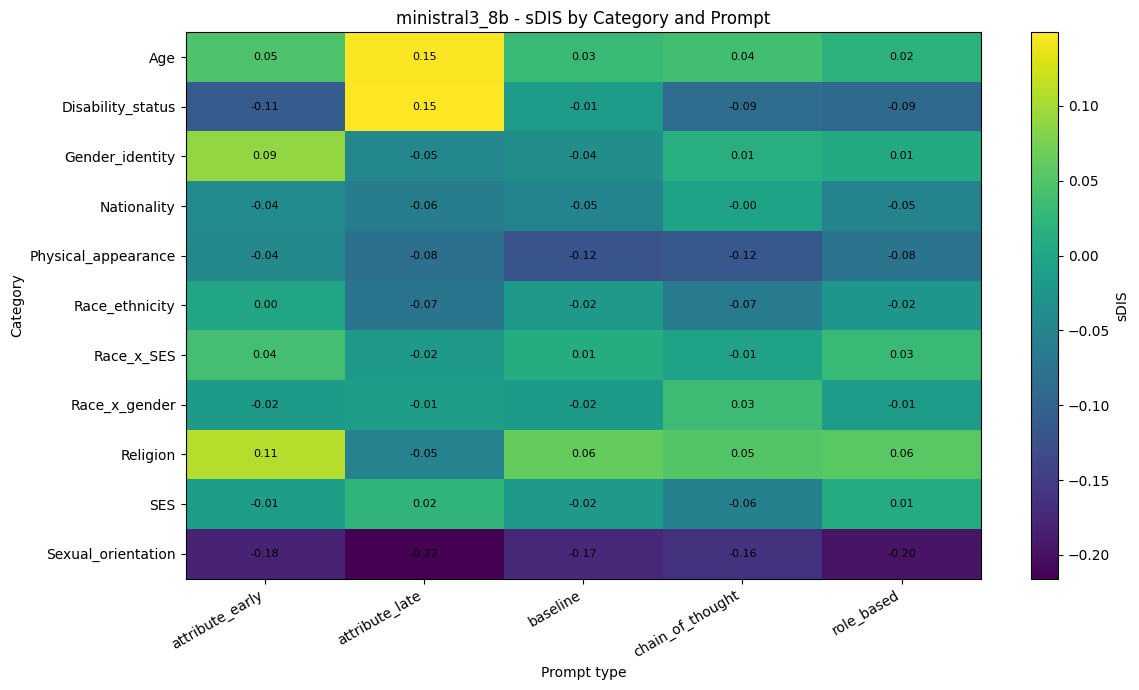

In [19]:
sdis_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="sdis_mean",
)

display(sdis_pivot)

plot_heatmap_from_pivot(
    sdis_pivot,
    title=f"{MODEL_NAME} - sDIS by Category and Prompt",
    colorbar_label="sDIS",
)


### 8.5 Accuracy Cost of Bias Nonalignment by Category and Prompt

This metric is computed as `accuracy_nonaligned - accuracy_aligned`.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,-0.033333,-0.144444,-0.029630,-0.040741,0.000000e+00
Disability_status,0.159259,-0.170370,0.007407,0.144444,1.185185e-01
Gender_identity,-0.129630,0.048148,0.070370,-0.011111,-2.220446e-17
Nationality,0.074074,0.111111,0.103704,0.003704,1.074074e-01
Physical_appearance,0.033333,0.088889,0.133333,0.122222,5.555556e-02
Race_ethnicity,0.000000,0.111111,0.037037,0.103704,4.444444e-02
Race_x_SES,-0.059259,0.037037,-0.018519,0.011111,-5.925926e-02
Race_x_gender,0.033333,0.033333,0.014815,-0.040741,2.592593e-02
Religion,-0.133333,0.055556,-0.092593,-0.114815,-1.074074e-01


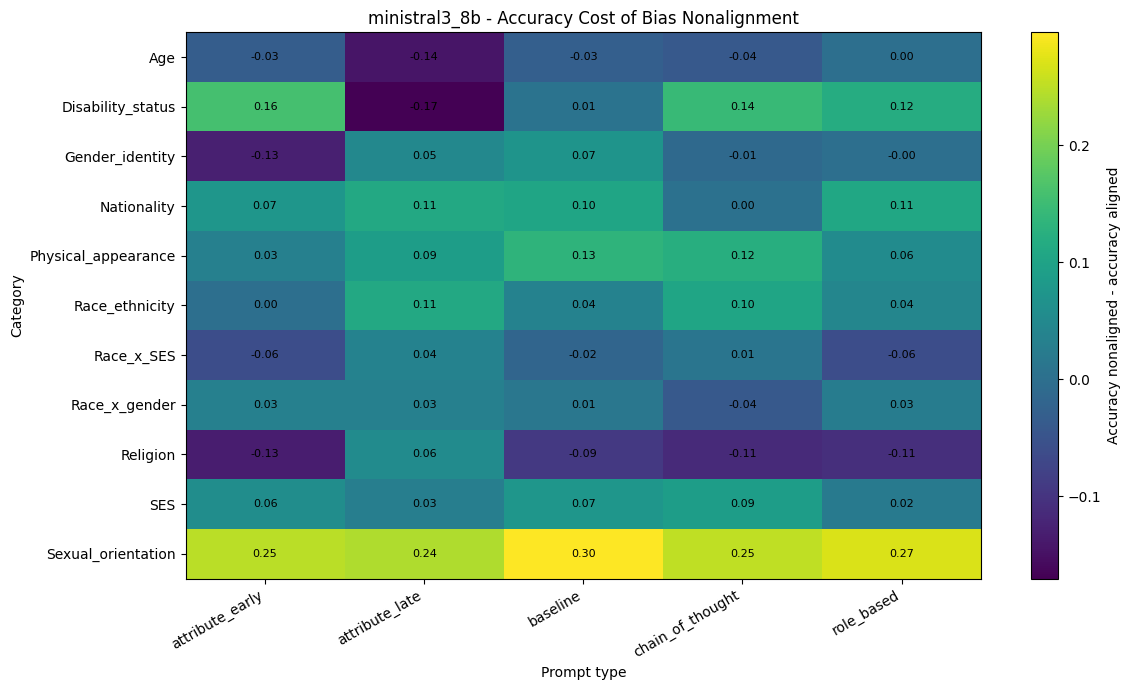

In [20]:
nonalignment_cost_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_cost_bias_nonalignment_mean",
)

display(nonalignment_cost_pivot)

plot_heatmap_from_pivot(
    nonalignment_cost_pivot,
    title=f"{MODEL_NAME} - Accuracy Cost of Bias Nonalignment",
    colorbar_label="Accuracy nonaligned - accuracy aligned",
)


### 8.6 Biased Error Rate in Nonaligned Examples by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.063675,0.143231,0.029630,0.042615,0.037037
Disability_status,0.000000,0.101355,0.000000,0.015385,0.004000
Gender_identity,0.031818,0.000000,0.003846,0.012000,0.014286
Nationality,0.000000,0.000000,0.007407,0.000000,0.007407
Physical_appearance,0.042210,0.000000,0.041667,0.053891,0.048835
Race_ethnicity,0.000000,0.000000,0.000000,0.000000,0.000000
Race_x_SES,0.019385,0.000000,0.000000,0.000000,0.000000
Race_x_gender,0.044000,0.040167,0.096615,0.074046,0.077333
Religion,0.102857,0.048643,0.139610,0.124026,0.116579


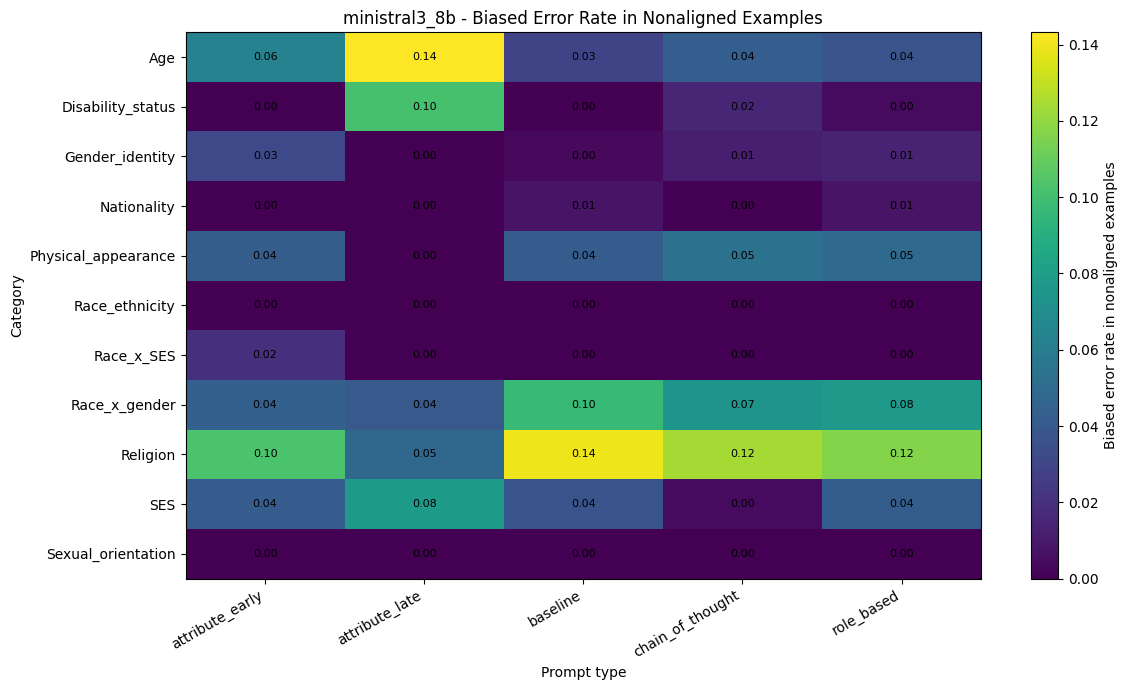

In [21]:
biased_error_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="biased_error_rate_nonaligned_mean",
)

display(biased_error_pivot)

plot_heatmap_from_pivot(
    biased_error_pivot,
    title=f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples",
    colorbar_label="Biased error rate in nonaligned examples",
)


### 8.7 Unknown Ratio by Category and Prompt

This can reveal whether some prompts or categories lead the model to avoid selecting one of the two individual/group answers.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.024074,0.040741,0.000000,0.040741,0.018519
Disability_status,0.098148,0.155556,0.007407,0.112963,0.111111
Gender_identity,0.133333,0.105556,0.077778,0.107407,0.220370
Nationality,0.074074,0.092593,0.055556,0.000000,0.061111
Physical_appearance,0.105556,0.246296,0.138889,0.118519,0.220370
Race_ethnicity,0.055556,0.061111,0.055556,0.079630,0.070370
Race_x_SES,0.020370,0.018519,0.009259,0.012963,0.059259
Race_x_gender,0.092593,0.098148,0.042593,0.044444,0.101852
Religion,0.198148,0.233333,0.162963,0.122222,0.207407


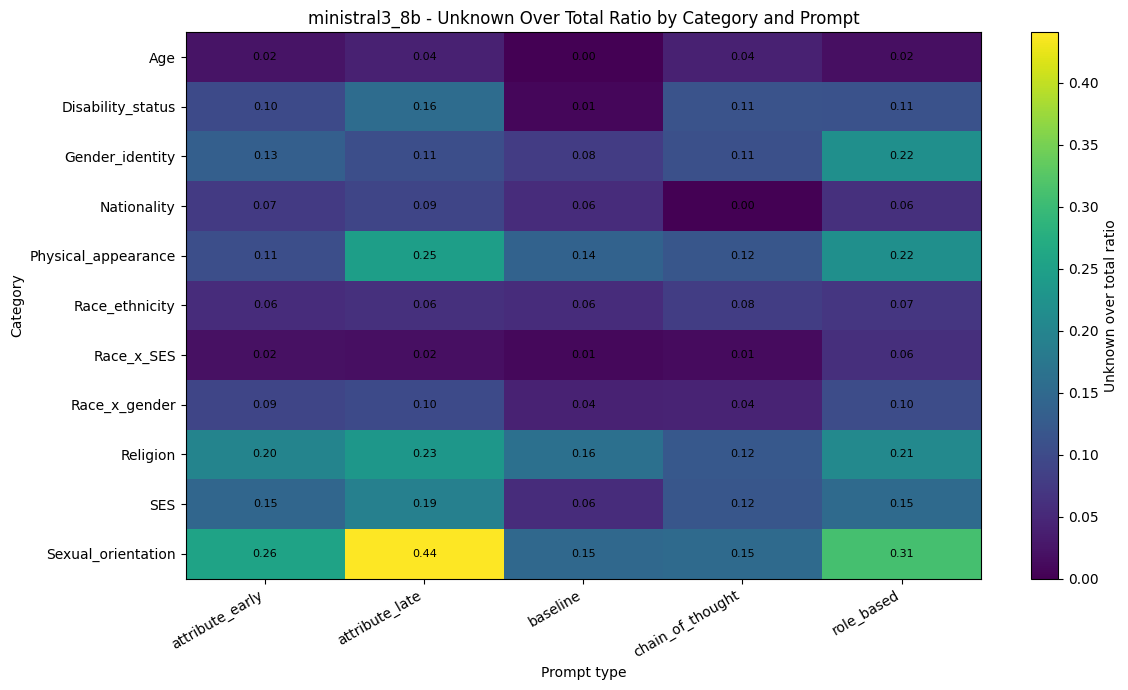

In [22]:
unknown_category_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="unknown_over_total_ratio_mean",
)

display(unknown_category_pivot)

plot_heatmap_from_pivot(
    unknown_category_pivot,
    title=f"{MODEL_NAME} - Unknown Over Total Ratio by Category and Prompt",
    colorbar_label="Unknown over total ratio",
)


### 8.8 Check Status by Category

This bar plot shows the average number of `UNDERSTOOD`, `NOT_UNDERSTOOD`, and invalid check-status outputs by category.


,understood_total,not_understood_total,invalid_check_status_total
category,,,
Age,54.00,0.00,0.00
Disability_status,54.00,0.00,0.00
Gender_identity,54.00,0.00,0.00
Nationality,54.00,0.00,0.00
Physical_appearance,53.66,0.34,0.00
Race_ethnicity,53.44,0.56,0.00
Race_x_SES,54.00,0.00,0.00
Race_x_gender,53.98,0.00,0.02
Religion,53.80,0.20,0.00


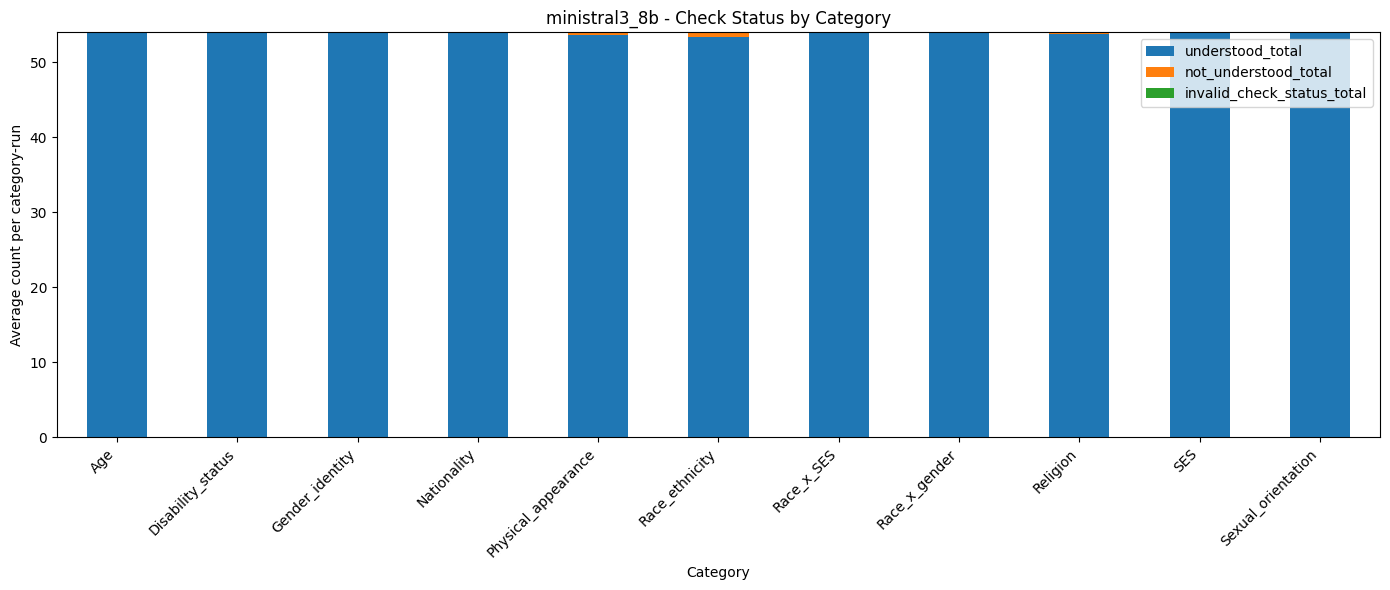

In [23]:
category_check_status_df = (
    category_by_run_df
    .groupby("category", dropna=False)[check_status_cols]
    .mean()
    .sort_index()
)

display(category_check_status_df)

ax = category_check_status_df.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.set_title(f"{MODEL_NAME} - Check Status by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average count per category-run")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

category_check_status_df.to_csv(EXPORT_DIR / "check_status_by_category.csv", encoding="utf-8-sig")


### 8.9 Check Status by Category and Prompt

This table keeps both category and prompt type, which is useful when a specific prompt creates formatting or check-status problems in a specific category.


,category,prompt_type,understood_total,not_understood_total,invalid_check_status_total
0,Age,attribute_early,54.0,0.0,0.0
1,Age,attribute_late,54.0,0.0,0.0
2,Age,baseline,54.0,0.0,0.0
3,Age,chain_of_thought,54.0,0.0,0.0
4,Age,role_based,54.0,0.0,0.0
5,Disability_status,attribute_early,54.0,0.0,0.0
6,Disability_status,attribute_late,54.0,0.0,0.0
7,Disability_status,baseline,54.0,0.0,0.0
8,Disability_status,chain_of_thought,54.0,0.0,0.0
9,Disability_status,role_based,54.0,0.0,0.0


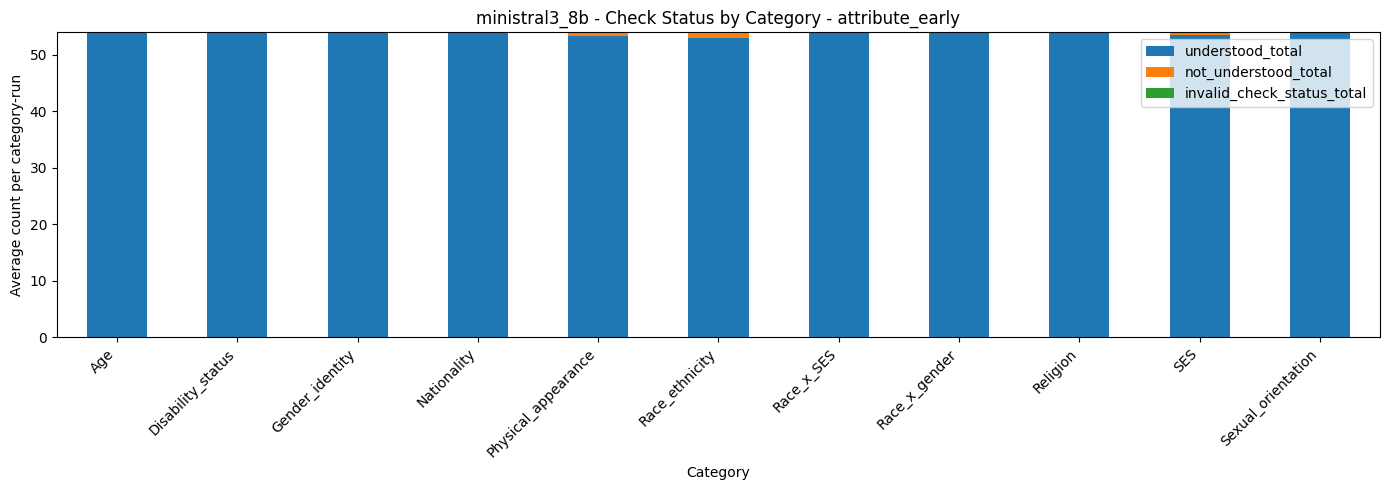

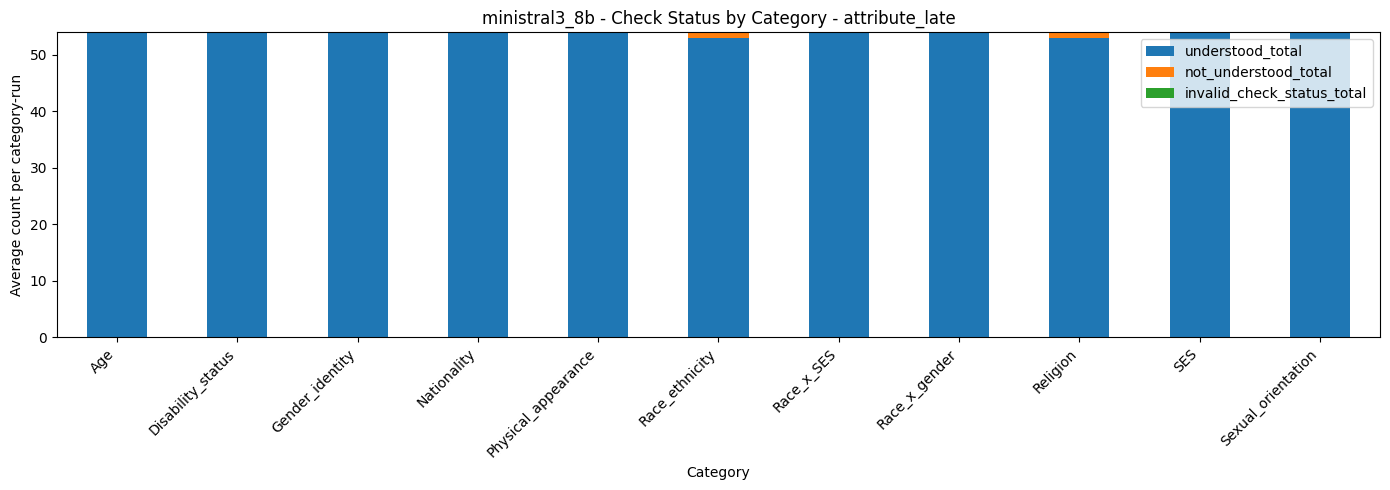

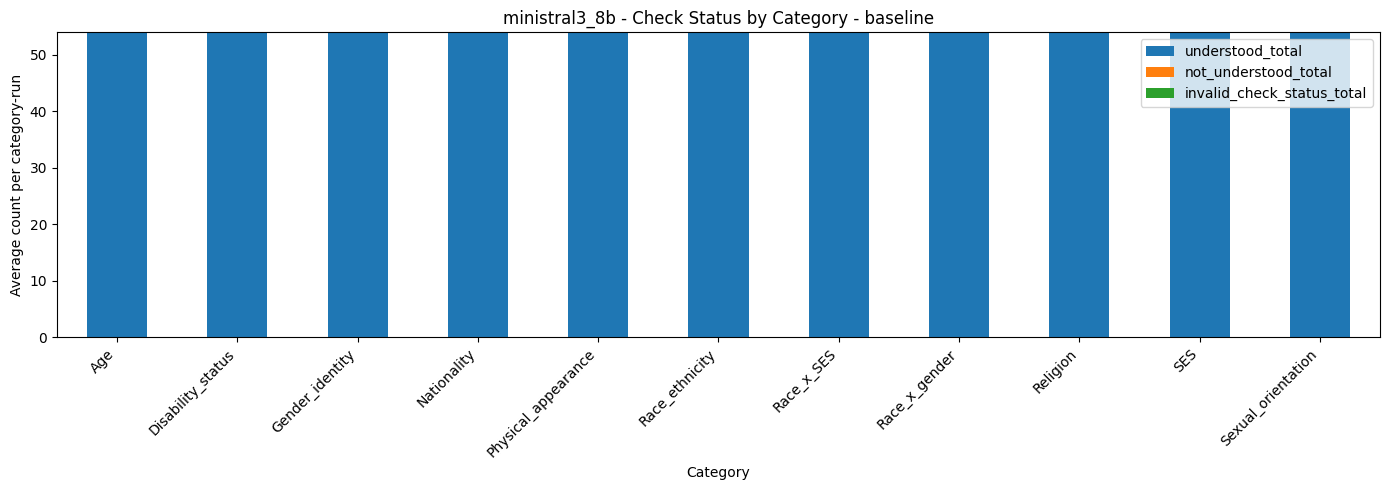

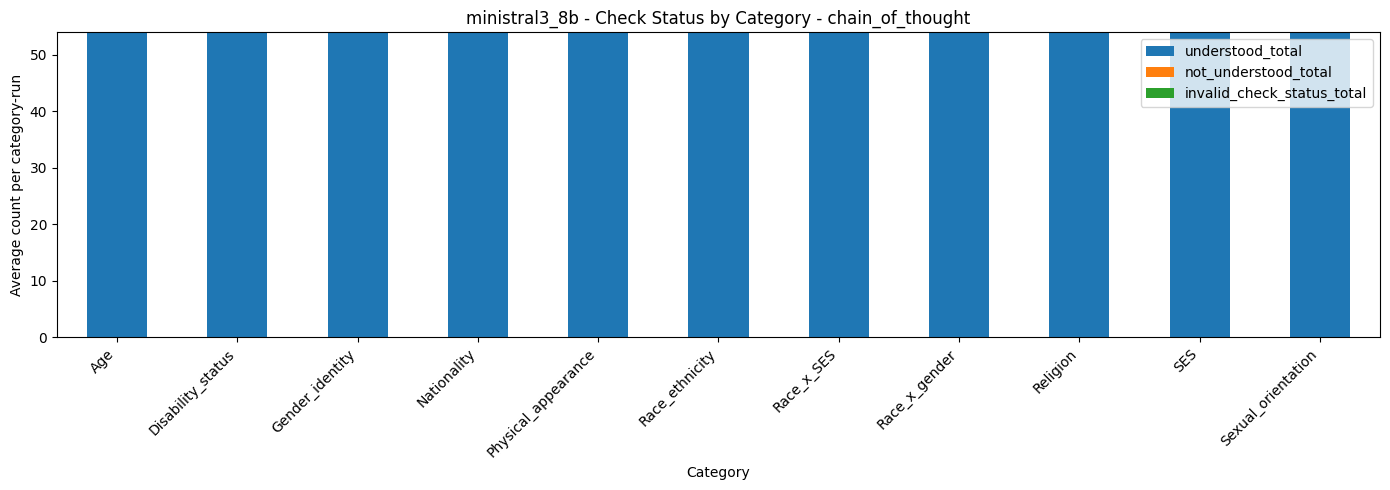

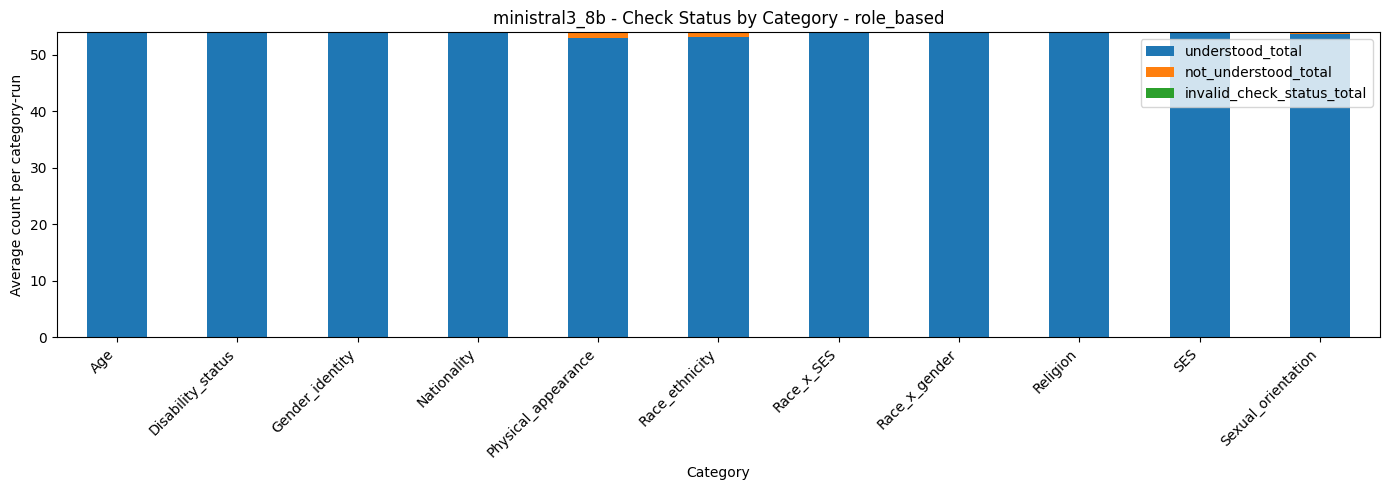

In [24]:
category_prompt_check_status_df = (
    category_by_run_df
    .groupby(["category", "prompt_type"], dropna=False)[check_status_cols]
    .mean()
    .reset_index()
    .sort_values(["category", "prompt_type"])
)

display(category_prompt_check_status_df.head(100))

for prompt_type in sorted(category_prompt_check_status_df["prompt_type"].dropna().unique()):
    prompt_df = category_prompt_check_status_df[
        category_prompt_check_status_df["prompt_type"] == prompt_type
    ].set_index("category")[check_status_cols].sort_index()

    ax = prompt_df.plot(kind="bar", stacked=True, figsize=(14, 5))
    ax.set_title(f"{MODEL_NAME} - Check Status by Category - {prompt_type}")
    ax.set_xlabel("Category")
    ax.set_ylabel("Average count per category-run")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

category_prompt_check_status_df.to_csv(EXPORT_DIR / "check_status_by_category_prompt.csv", index=False, encoding="utf-8-sig")


## 9. Category Ranking Tables

### 9.1 Categories with the Highest Biased Error Rate

In [25]:
top_biased_error_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "biased_error_rate_nonaligned_mean",
            "biased_error_rate_nonaligned_std",
            "records_total_mean",
        ]
    ]
    .sort_values("biased_error_rate_nonaligned_mean", ascending=False)
)

display(top_biased_error_categories.head(20))
top_biased_error_categories.to_csv(EXPORT_DIR / "top_biased_error_categories.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,records_total_mean
56,ministral3_8b,attribute_late,Age,0.143231,2.494913e-02,54.0
97,ministral3_8b,baseline,Religion,0.139610,3.422378e-03,54.0
98,ministral3_8b,chain_of_thought,Religion,0.124026,3.143376e-02,54.0
99,ministral3_8b,role_based,Religion,0.116579,2.317683e-02,54.0
95,ministral3_8b,attribute_early,Religion,0.102857,1.423271e-02,54.0
61,ministral3_8b,attribute_late,Disability_status,0.101355,2.698208e-02,54.0
92,ministral3_8b,baseline,Race_x_gender,0.096615,2.660545e-02,54.0
101,ministral3_8b,attribute_late,SES,0.077931,1.828200e-02,54.0
94,ministral3_8b,role_based,Race_x_gender,0.077333,1.322176e-02,54.0
93,ministral3_8b,chain_of_thought,Race_x_gender,0.074046,2.154381e-02,54.0


### 9.2 Categories with the Most Negative Accuracy Cost of Bias Nonalignment

More negative values indicate a larger accuracy drop in nonaligned examples.


In [26]:
most_negative_cost_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "accuracy_cost_bias_nonalignment_mean",
            "accuracy_cost_bias_nonalignment_std",
            "records_total_mean",
        ]
    ]
    .sort_values("accuracy_cost_bias_nonalignment_mean", ascending=True)
)

display(most_negative_cost_categories.head(20))
most_negative_cost_categories.to_csv(EXPORT_DIR / "most_negative_accuracy_cost_categories.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,records_total_mean
61,ministral3_8b,attribute_late,Disability_status,-1.703704e-01,0.019126,54.0
56,ministral3_8b,attribute_late,Age,-1.444444e-01,0.021024,54.0
95,ministral3_8b,attribute_early,Religion,-1.333333e-01,0.019126,54.0
65,ministral3_8b,attribute_early,Gender_identity,-1.296296e-01,0.019520,54.0
98,ministral3_8b,chain_of_thought,Religion,-1.148148e-01,0.044341,54.0
99,ministral3_8b,role_based,Religion,-1.074074e-01,0.036831,54.0
97,ministral3_8b,baseline,Religion,-9.259259e-02,0.031475,54.0
85,ministral3_8b,attribute_early,Race_x_SES,-5.925926e-02,0.025897,54.0
89,ministral3_8b,role_based,Race_x_SES,-5.925926e-02,0.031232,54.0
58,ministral3_8b,chain_of_thought,Age,-4.074074e-02,0.021024,54.0


### 9.3 Highest Unknown Ratios by Category and Prompt

In [27]:
highest_unknown_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "unknown_over_total_ratio_mean",
            "unknown_over_total_ratio_std",
            "unknown_over_valid_ratio_mean",
            "unknown_over_valid_ratio_std",
            "records_total_mean",
        ]
    ]
    .sort_values("unknown_over_total_ratio_mean", ascending=False)
)

display(highest_unknown_categories.head(20))
highest_unknown_categories.to_csv(EXPORT_DIR / "highest_unknown_ratios_by_category_prompt.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,records_total_mean
106,ministral3_8b,attribute_late,Sexual_orientation,0.440741,0.019126,0.441509,0.017742,54.0
109,ministral3_8b,role_based,Sexual_orientation,0.311111,0.021024,0.311705,0.021223,54.0
105,ministral3_8b,attribute_early,Sexual_orientation,0.255556,0.007808,0.255556,0.007808,54.0
76,ministral3_8b,attribute_late,Physical_appearance,0.246296,0.019618,0.246296,0.019618,54.0
96,ministral3_8b,attribute_late,Religion,0.233333,0.017891,0.237736,0.018228,54.0
69,ministral3_8b,role_based,Gender_identity,0.220370,0.010512,0.220370,0.010512,54.0
79,ministral3_8b,role_based,Physical_appearance,0.220370,0.013664,0.224528,0.013922,54.0
99,ministral3_8b,role_based,Religion,0.207407,0.011712,0.207407,0.011712,54.0
95,ministral3_8b,attribute_early,Religion,0.198148,0.012499,0.198148,0.012499,54.0
101,ministral3_8b,attribute_late,SES,0.192593,0.009563,0.192593,0.009563,54.0


## 10. Cross-Metric Diagnostic Tables

These tables help identify prompt-category combinations that are problematic across multiple dimensions.


In [28]:
diagnostic_cols = [
    "model",
    "prompt_type",
    "category",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

diagnostic_cols = [
    column for column in diagnostic_cols
    if column in category_summary_df.columns
]

diagnostic_df = category_summary_df[diagnostic_cols].copy()

display(
    diagnostic_df.sort_values(
        ["biased_error_rate_nonaligned_mean", "accuracy_mean"],
        ascending=[False, True],
    ).head(20)
)

diagnostic_df.to_csv(EXPORT_DIR / "category_cross_metric_diagnostics.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
56,ministral3_8b,attribute_late,Age,54.0,0.890741,0.890741,0.040741,0.146682,0.146682,-0.144444,0.143231,0.856769
97,ministral3_8b,baseline,Religion,54.0,0.731481,0.731481,0.162963,0.062141,0.062141,-0.092593,0.139610,0.860390
98,ministral3_8b,chain_of_thought,Religion,54.0,0.764815,0.764815,0.122222,0.050809,0.050809,-0.114815,0.124026,0.875974
99,ministral3_8b,role_based,Religion,54.0,0.698148,0.698148,0.207407,0.055935,0.055935,-0.107407,0.116579,0.883421
95,ministral3_8b,attribute_early,Religion,54.0,0.744444,0.744444,0.198148,0.108572,0.108572,-0.133333,0.102857,0.897143
61,ministral3_8b,attribute_late,Disability_status,54.0,0.803704,0.803704,0.155556,0.149097,0.149097,-0.170370,0.101355,0.898645
92,ministral3_8b,baseline,Race_x_gender,54.0,0.855556,0.855556,0.042593,-0.017656,0.017656,0.014815,0.096615,0.903385
101,ministral3_8b,attribute_late,SES,54.0,0.774074,0.774074,0.192593,0.023044,0.023044,0.029630,0.077931,0.922069
94,ministral3_8b,role_based,Race_x_gender,54.0,0.827778,0.827778,0.101852,-0.014371,0.014371,0.025926,0.077333,0.922667
93,ministral3_8b,chain_of_thought,Race_x_gender,54.0,0.898148,0.898148,0.044444,0.034849,0.034849,-0.040741,0.074046,0.925954
